In [1]:
# Notebook 2 : Autoencodeur Variationnel (VAE) sur MNIST

# **Objectif** : Étendre l'autoencodeur simple en imposant une structure probabiliste sur l'espace latent (loi normale). Nous apprendrons une distribution gaussienne paramétrée par moyenne et variance logarithmique, puis nous générerons de nouveaux chiffres en échantillonnant depuis cette distribution.

In [2]:
## 1. Imports et configuration

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Pour visualiser l'espace latent (optionnel)
from sklearn.manifold import TSNE

# Fixer les graines pour reproductibilité
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [5]:
## 2. Chargement des données (identique au notebook 1)

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # sortie dans [-1, 1] pour tanh
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Taille train: {len(train_dataset)}, test: {len(test_dataset)}")

Taille train: 60000, test: 10000


In [7]:
## 3. Définition du modèle VAE

# Le VAE produit deux vecteurs pour l'espace latent : `mu` (moyenne) et `log_var` (log de la variance).  
# Le reparametrization trick : `z = mu + exp(log_var/2) * epsilon` où epsilon ~ N(0,I).  
# La fonction de perte = reconstruction (MSE) + KL divergence.

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encodeur : mêmes couches que l'autoencodeur simple
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*7*7, 128),
            nn.ReLU()
        )
        # Couches pour mu et log_var
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Décodeur : identique à l'autoencodeur simple
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32*7*7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        # Reparametrization trick
        std = torch.exp(0.5 * log_var)  # écart-type
        eps = torch.randn_like(std)      # bruit gaussien
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

# Instanciation
latent_dim = 20   # dimension de l'espace latent (pour visualisation 2D plus tard)
model = VAE(latent_dim=latent_dim).to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=1568, out_features=128, bias=True)
    (6): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (8): Tanh()
  )
)


In [9]:
## 4. Fonction de perte : reconstruction + KL divergence

# - Reconstruction : MSE entre image originale et reconstruite.
# - KL divergence : D_KL( N(mu, sigma^2) || N(0,1) ) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)

In [3]:
def loss_vae(recon, x, mu, log_var):
    # Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # Perte totale (moyennée sur le batch)
    total_loss = (recon_loss + kl_loss) / x.size(0)
    return total_loss, recon_loss / x.size(0), kl_loss / x.size(0)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

NameError: name 'optim' is not defined

In [11]:
## 5. Entraînement du VAE

# Nous entraînons pendant 20 époques, en affichant les pertes et des reconstructions périodiques.

Epoch [1/20] - Total Loss: 159.7180 (Recon: 146.1631, KL: 13.5549)
Epoch [2/20] - Total Loss: 88.7146 (Recon: 64.8436, KL: 23.8710)
Epoch [3/20] - Total Loss: 77.3806 (Recon: 52.0230, KL: 25.3577)
Epoch [4/20] - Total Loss: 72.4366 (Recon: 46.5079, KL: 25.9288)
Epoch [5/20] - Total Loss: 69.7463 (Recon: 43.4862, KL: 26.2601)


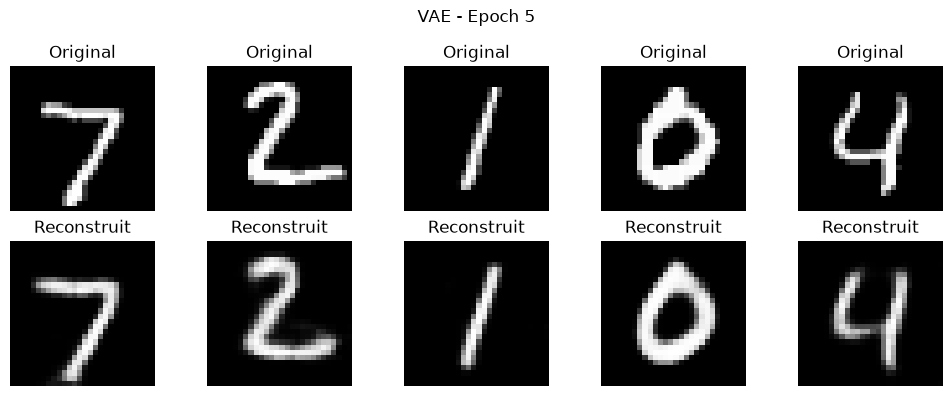

Epoch [6/20] - Total Loss: 68.2293 (Recon: 41.7745, KL: 26.4548)
Epoch [7/20] - Total Loss: 66.9315 (Recon: 40.3579, KL: 26.5737)
Epoch [8/20] - Total Loss: 66.0867 (Recon: 39.4493, KL: 26.6375)
Epoch [9/20] - Total Loss: 65.2919 (Recon: 38.6067, KL: 26.6852)
Epoch [10/20] - Total Loss: 64.6426 (Recon: 37.9808, KL: 26.6618)


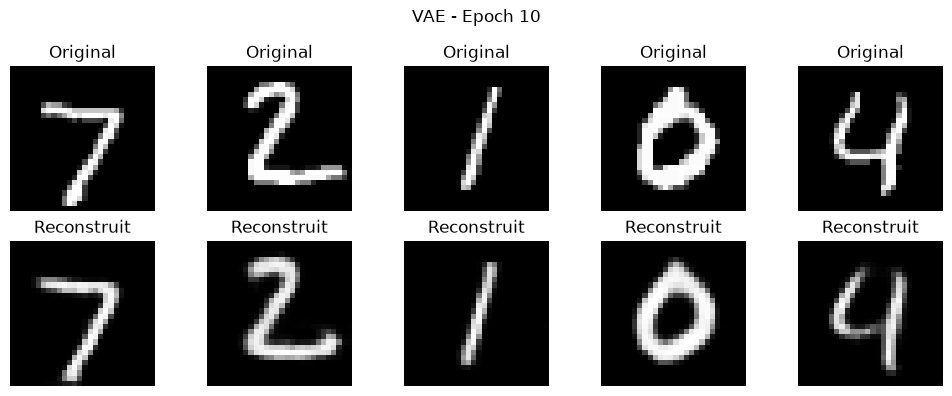

Epoch [11/20] - Total Loss: 64.1268 (Recon: 37.4242, KL: 26.7026)
Epoch [12/20] - Total Loss: 63.6149 (Recon: 36.8897, KL: 26.7252)
Epoch [13/20] - Total Loss: 63.2416 (Recon: 36.5473, KL: 26.6943)
Epoch [14/20] - Total Loss: 62.9208 (Recon: 36.1893, KL: 26.7315)
Epoch [15/20] - Total Loss: 62.5995 (Recon: 35.9162, KL: 26.6833)


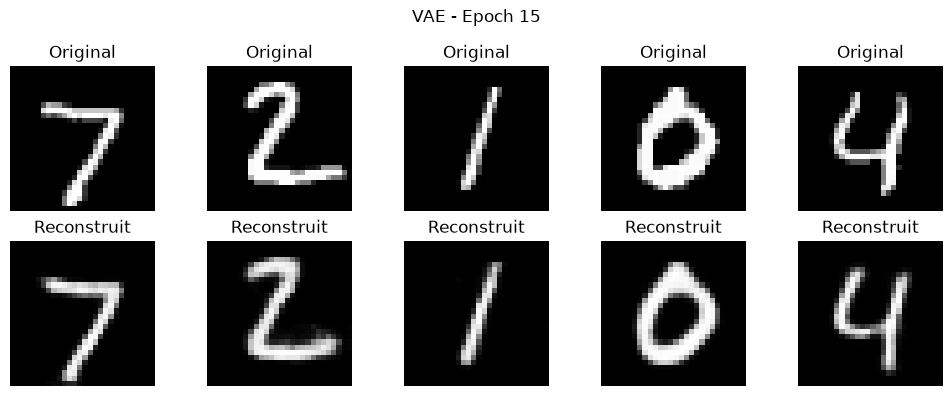

Epoch [16/20] - Total Loss: 62.3485 (Recon: 35.5957, KL: 26.7528)
Epoch [17/20] - Total Loss: 62.0150 (Recon: 35.3216, KL: 26.6934)
Epoch [18/20] - Total Loss: 61.8427 (Recon: 35.1512, KL: 26.6915)
Epoch [19/20] - Total Loss: 61.5758 (Recon: 34.8898, KL: 26.6860)
Epoch [20/20] - Total Loss: 61.3236 (Recon: 34.6574, KL: 26.6662)


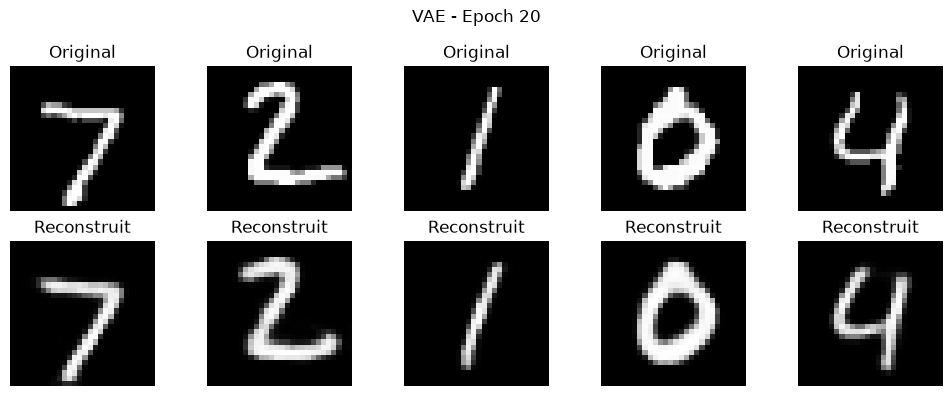

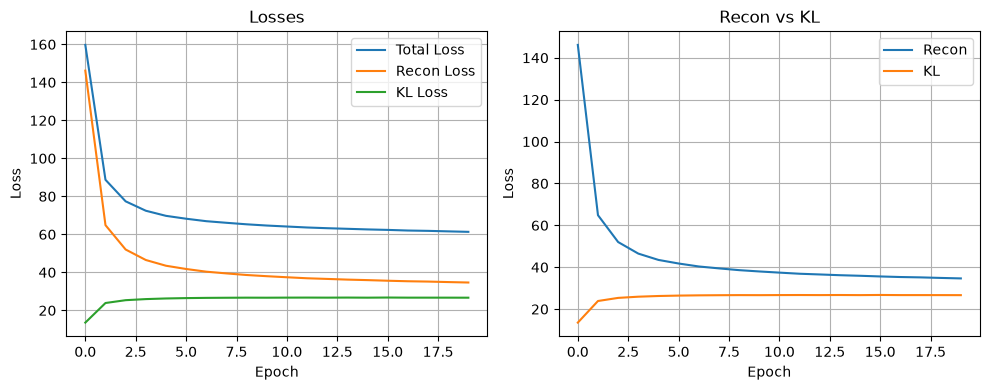

In [12]:
num_epochs = 20
train_losses = []
recon_losses = []
kl_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_total = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        
        recon, mu, log_var = model(images)
        loss, rl, kl = loss_vae(recon, images, mu, log_var)
        
        loss.backward()
        optimizer.step()
        
        epoch_total += loss.item() * images.size(0)
        epoch_recon += rl.item() * images.size(0)
        epoch_kl += kl.item() * images.size(0)
    
    avg_total = epoch_total / len(train_loader.dataset)
    avg_recon = epoch_recon / len(train_loader.dataset)
    avg_kl = epoch_kl / len(train_loader.dataset)
    train_losses.append(avg_total)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Total Loss: {avg_total:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")
    
    # Visualisation périodique
    if (epoch+1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            test_images, _ = next(iter(test_loader))
            test_images = test_images.to(device)
            recon_images, _, _ = model(test_images)
            
            fig, axes = plt.subplots(2, 5, figsize=(10, 4))
            for i in range(5):
                axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
                axes[0, i].set_title("Original")
                axes[0, i].axis('off')
                axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
                axes[1, i].set_title("Reconstruit")
                axes[1, i].axis('off')
            plt.suptitle(f"VAE - Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()

# Courbes d'apprentissage
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Total Loss')
plt.plot(recon_losses, label='Recon Loss')
plt.plot(kl_losses, label='KL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Losses')

# Zoom sur les composantes
plt.subplot(1,2,2)
plt.plot(recon_losses, label='Recon')
plt.plot(kl_losses, label='KL')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Recon vs KL')
plt.tight_layout()
plt.show()

In [13]:
## 6. Génération de nouveaux chiffres

# On échantillonne depuis la loi normale N(0,I) et on passe par le décodeur.

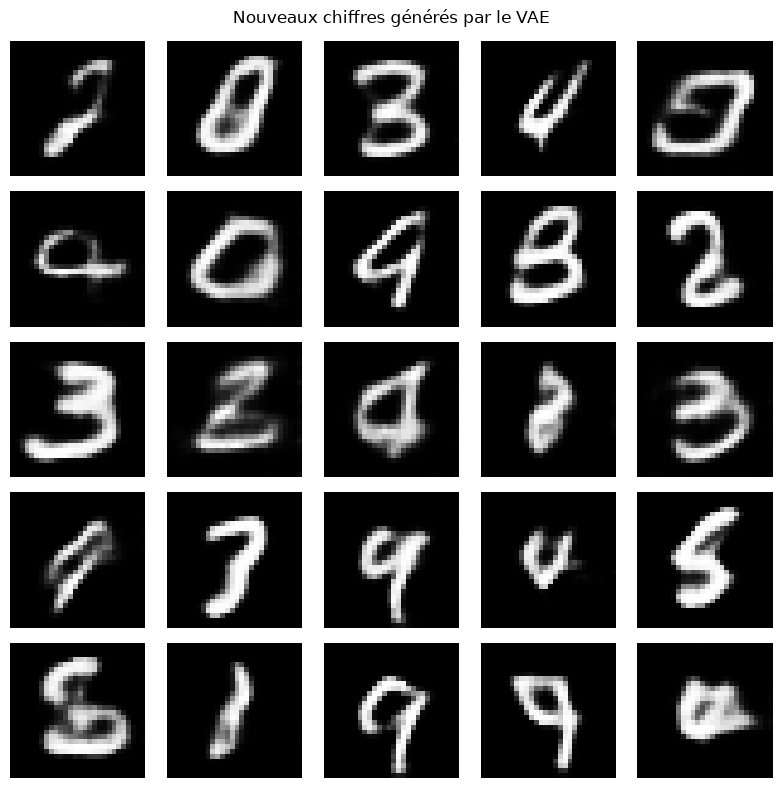

In [18]:
def generate_digits(model, num_samples=25, latent_dim=20):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = model.decode(z).cpu()
    
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Nouveaux chiffres générés par le VAE")
    plt.tight_layout()
    plt.show()

generate_digits(model, num_samples=25, latent_dim=latent_dim)

In [14]:
## 7. Visualisation de l'espace latent (2D avec t-SNE)

# Pour comprendre comment les différentes classes (chiffres) sont organisées dans l'espace latent.

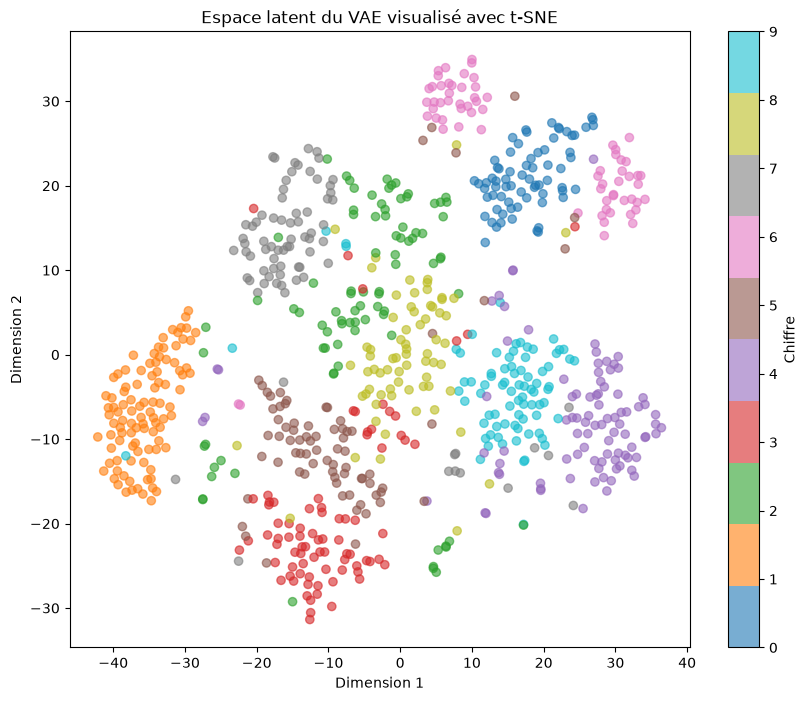

In [19]:
def plot_latent_space(model, data_loader, num_samples=500):
    model.eval()
    z_list = []
    label_list = []
    with torch.no_grad():
        for i, (images, labels) in enumerate(data_loader):
            if i * batch_size >= num_samples:
                break
            images = images.to(device)
            mu, _ = model.encode(images)  # on prend la moyenne
            z_list.append(mu.cpu().numpy())
            label_list.append(labels.numpy())
    z = np.concatenate(z_list, axis=0)[:num_samples]
    labels = np.concatenate(label_list, axis=0)[:num_samples]
    
    # t-SNE pour réduire à 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    z_2d = tsne.fit_transform(z)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
    plt.colorbar(scatter, label='Chiffre')
    plt.title("Espace latent du VAE visualisé avec t-SNE")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# Appel (attention, peut être lent)
plot_latent_space(model, test_loader, num_samples=800)

In [15]:
## 8. Interpolation entre deux chiffres

# On prend deux vecteurs latents correspondant à deux images, on interpole linéairement et on décode.

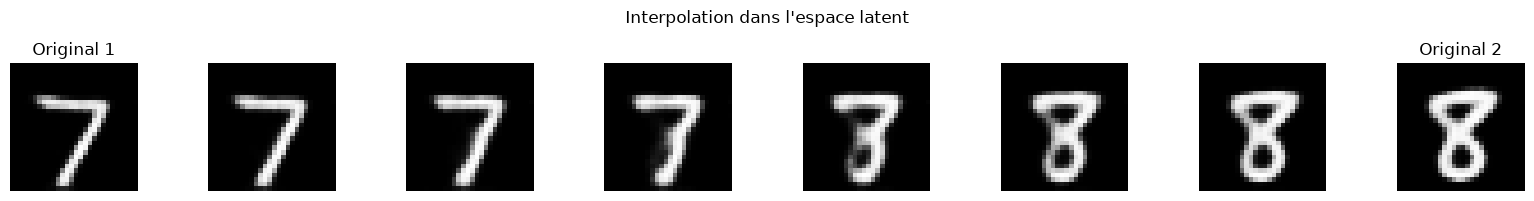

In [20]:
def interpolate(model, img1, img2, steps=8):
    model.eval()
    with torch.no_grad():
        mu1, _ = model.encode(img1.unsqueeze(0).to(device))
        mu2, _ = model.encode(img2.unsqueeze(0).to(device))
        
        alphas = np.linspace(0, 1, steps)
        interpolated = []
        for alpha in alphas:
            z = (1-alpha) * mu1 + alpha * mu2
            recon = model.decode(z).cpu()
            interpolated.append(recon.squeeze())
    
    fig, axes = plt.subplots(1, steps, figsize=(steps*2, 2))
    for i, img in enumerate(interpolated):
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        if i == 0:
            axes[i].set_title("Original 1")
        elif i == steps-1:
            axes[i].set_title("Original 2")
    plt.suptitle("Interpolation dans l'espace latent")
    plt.tight_layout()
    plt.show()

# Exemple : deux premiers chiffres du test loader
test_iter = iter(test_loader)
img1, label1 = next(test_iter)
img2, label2 = next(test_iter)
interpolate(model, img1[0], img2[0], steps=8)

In [16]:
## 9. Sauvegarde du modèle VAE

In [21]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/vae_mnist.pth")
print("Modèle VAE sauvegardé dans ../models/vae_mnist.pth")

Modèle VAE sauvegardé dans ../models/vae_mnist.pth


In [17]:
## 10. Conclusion

# Le VAE apprend un espace latent continu et régularisé qui permet :
# - Une reconstruction fidèle
# - La génération de nouveaux échantillons réalistes
# - Des interpolations fluides entre chiffres

# Dans le notebook suivant, nous implémenterons un GAN classique puis sa variante plus stable WGAN-GP.

In [2]:
print(f"test_loss : {total_loss:.4f}")

NameError: name 'total_loss' is not defined